# Binary Classification 
## Predicting Diabetes Using the Pima Indians Diabetes Dataset
### Data Mining and Machine Learning Final Project 
*Powered by Pycaret*

This notebook demonstrates a complete end-to-end binary classification workflow using PyCaret, a low-code Python library that simplifies and accelerates machine learning experimentation. We will perform data preprocessing, exploratory analysis, and model comparison using two pipelines—one with full cleaned features and one with feature selection—to determine the most effective model for predicting diabetes.

#### About the Dataset: Pima Indians Diabetes Database

This dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases and has been widely used in medical ML research. It contains 768 instances of female patients (≥21 years old) of Pima Indian heritage residing near Phoenix, Arizona. The goal is to predict whether a patient tests positive for diabetes, based on 8 clinical measurements.

Key Details
- Instances: 768
- Attributes: 8 predictors + 1 binary target
- Target Variable:
- 0 → tested_negative
- 1 → tested_positive

Class Distribution:
- 500 negative
- 268 positive

Missing Values: None
Attribute List:
- Number of pregnancies
- Plasma glucose concentration (2-hour oral glucose test)
- Diastolic blood pressure
- Triceps skin fold thickness
- 2-hour serum insulin
- BMI
- Diabetes pedigree function
- Age

This dataset has been studied in foundational work by Smith et al. (1988), which demonstrated early prediction performance using the ADAP learning algorithm.

#### Table of Contents
1. **Data Preprocessing**
   
    1.1 Exploratory Data Analysis
   
    1.2 Data Cleaning
   
    1.3 Key Takeaways
   
    1.4 Final Dataset
   
2. **Model Training, Comparison, and Evaluation**


   2.1 Pipeline A: Cleaned Data (No Feature Selection)


   2.2 Pipeline B: Cleaned Data (With Feature Selection)

   
3. **Combined Results**

   
    3.1 Full vs. Feature-Selected Pipeline Comparison

   
    3.2 Overall Best Performing Model

   
4. **Analyze Model**

## Notebook Setup

In [1]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'catboost_info', 'Datasets.ipynb', 'diabetes.arff', 'ISCS_FinalProject_MFranklin_.ipynb', 'logs.log', 'my_first_pipeline.pkl', 'pycaret-env.yml', 'README.md', 'settings.txt', 'Tutorial - Binary Classification-Copy1.ipynb']


In [2]:
import pycaret, sklearn, numpy, scipy, sys, os
print("pycaret", pycaret.__version__)
print("sklearn", sklearn.__version__)
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("python exe", sys.executable)


pycaret 3.3.2
sklearn 1.4.2
numpy 1.26.4
scipy 1.10.1
python exe C:\Users\mfranklin3409\AppData\Local\anaconda3\envs\pycaret-env\python.exe


In [3]:
# Import Libraires
from scipy.io import arff
import pandas as pd
import numpy as np

In [4]:
# set the file path to local dir
file_path = 'diabetes.arff'

try:
    # Load the ARFF data
    data, meta = arff.loadarff(file_path)

    # Convert to pandas DataFrame for easier manipulation
    data1 = pd.DataFrame(data)
    print("ARFF file loaded successfully!")
    print("First 5 rows of the DataFrame:")
    print(data1.head())
    print("\nMetadata:")
    for attribute in meta:
        print(f"  {attribute}: {meta[attribute]}")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and make sure it's uploaded.")
except Exception as e:
    print(f"An error occurred: {e}")

ARFF file loaded successfully!
First 5 rows of the DataFrame:
   preg   plas  pres  skin   insu  mass   pedi   age               class
0   6.0  148.0  72.0  35.0    0.0  33.6  0.627  50.0  b'tested_positive'
1   1.0   85.0  66.0  29.0    0.0  26.6  0.351  31.0  b'tested_negative'
2   8.0  183.0  64.0   0.0    0.0  23.3  0.672  32.0  b'tested_positive'
3   1.0   89.0  66.0  23.0   94.0  28.1  0.167  21.0  b'tested_negative'
4   0.0  137.0  40.0  35.0  168.0  43.1  2.288  33.0  b'tested_positive'

Metadata:
  preg: ('numeric', None)
  plas: ('numeric', None)
  pres: ('numeric', None)
  skin: ('numeric', None)
  insu: ('numeric', None)
  mass: ('numeric', None)
  pedi: ('numeric', None)
  age: ('numeric', None)
  class: ('nominal', ('tested_negative', 'tested_positive'))


### Data Proprocessing

##### Label Encoding

In [5]:
# Convert the target column to a binary 0 and 1
# Target = Class varible
# (class value 1 is interpreted as "tested positive" and value 0 as "tested negative" for % diabetes")

# Decode the byte strings to regular strings
data1['class'] = data1['class'].apply(lambda x: x.decode('utf-8'))

# Then, replace the string values with integers
data1['class'] = data1['class'].replace({'tested_positive': 1, 'tested_negative': 0})

# Finally, convert to integer type
data1['class'] = data1['class'].astype(int)
data1.head()





,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [6]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    float64
 1   plas    768 non-null    float64
 2   pres    768 non-null    float64
 3   skin    768 non-null    float64
 4   insu    768 non-null    float64
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    float64
 8   class   768 non-null    int32  
dtypes: float64(8), int32(1)
memory usage: 51.1 KB


**Note:** 

It's appropriate to have a mix of float and integer columns in your diabetes dataset for machine learning for several reasons, reflecting the nature of the data itself:

**Integer Columns:** These typically represent counts, discrete categories, or measurements that are usually reported as whole numbers. For example, you can't be '2.5 times pregnant' or have an 'age of 31.7 years' in this context (though age can be continuous, it's often recorded as integers).
- Represents Discrete Nature: It accurately reflects that these values are whole numbers, which can be important for some algorithms.
- Prevents Misinterpretation: For features like 'Number of times pregnant', a fractional value wouldn't make sense.

Using integers for these features:
- 'Number of times pregnant',
- 'Age (years)', 'Diastolic blood pressure (mm Hg)',
- '2-Hour serum insulin (mu U/ml)', 'Triceps skin fold thickness (mm)',
- 'Plasma glucose concentration a 2 hours in an oral glucose tolerance test'): 


**Float Columns:** These columns represent continuous measurements or ratios that can naturally have decimal values. For instance:
- 'Body mass index' (BMI): This is a calculated ratio and often includes decimal places (e.g., 25.3). Rounding it to an integer might lose valuable precision.
- 'Diabetes pedigree function': This is a genetic score that likely ranges continuously and includes decimal values. Rounding it would distort the precision of the hereditary risk factor.

*Interpretability: Correct data types make the model and its inputs easier to understand and interpret.
In summary, the choice of float or integer depends on whether the underlying characteristic being measured is inherently continuous or discrete. Mostly integers for counts/discrete measures and floats for continuous metrics like BMI and pedigree function is appropriate for accurately representing the dataset for machine learning.*

##### Convert float to integer

In [10]:
# Convert specific columns from float to int
integer_columns = [
    'preg',
    'plas',
    'pres',
    'skin',
    'insu',
    'age'
]

# Apply integer conversion to the specified columns
for col in integer_columns:
    if col in data1.columns and data1[col].dtype == 'float64':
        data1[col] = data1[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data1.info())
data1.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int32  
dtypes: float64(2), int32(1), int64(6)
memory usage: 51.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# Check for missing values
print('Missing values in each column:')
data1.isnull().sum()

Missing values in each column:


preg     0
plas     0
pres     0
skin     0
insu     0
mass     0
pedi     0
age      0
class    0
dtype: int64

**Target Variable Class Distribution**

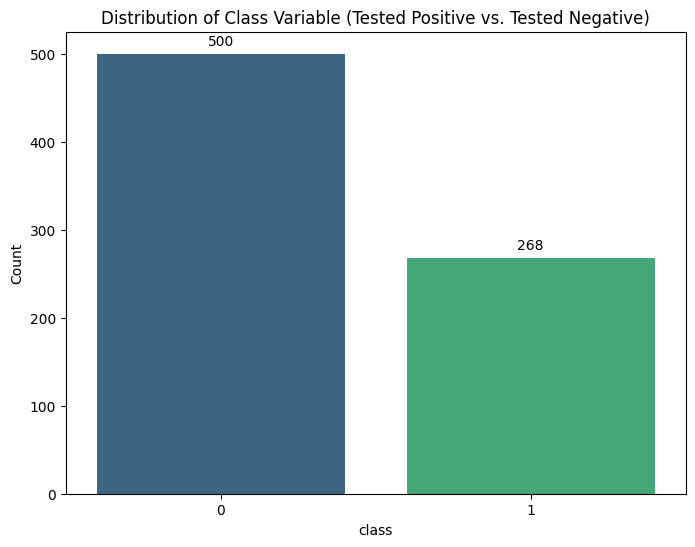

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the counts of each class
class_counts = data1['class'].value_counts()

# Map integer labels back to original string labels for better readability in the plot
class_labels = {1:1, 0:0}
class_counts.index = class_counts.index.map(class_labels)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of Class Variable (Tested Positive vs. Tested Negative)')
plt.xlabel('class')
plt.ylabel('Count')
plt.xticks(rotation=0) # Keep labels horizontal

# Add total count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

plt.show()

#### Exploratory Data Analysis

In [13]:
# Summary Stats
data1.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


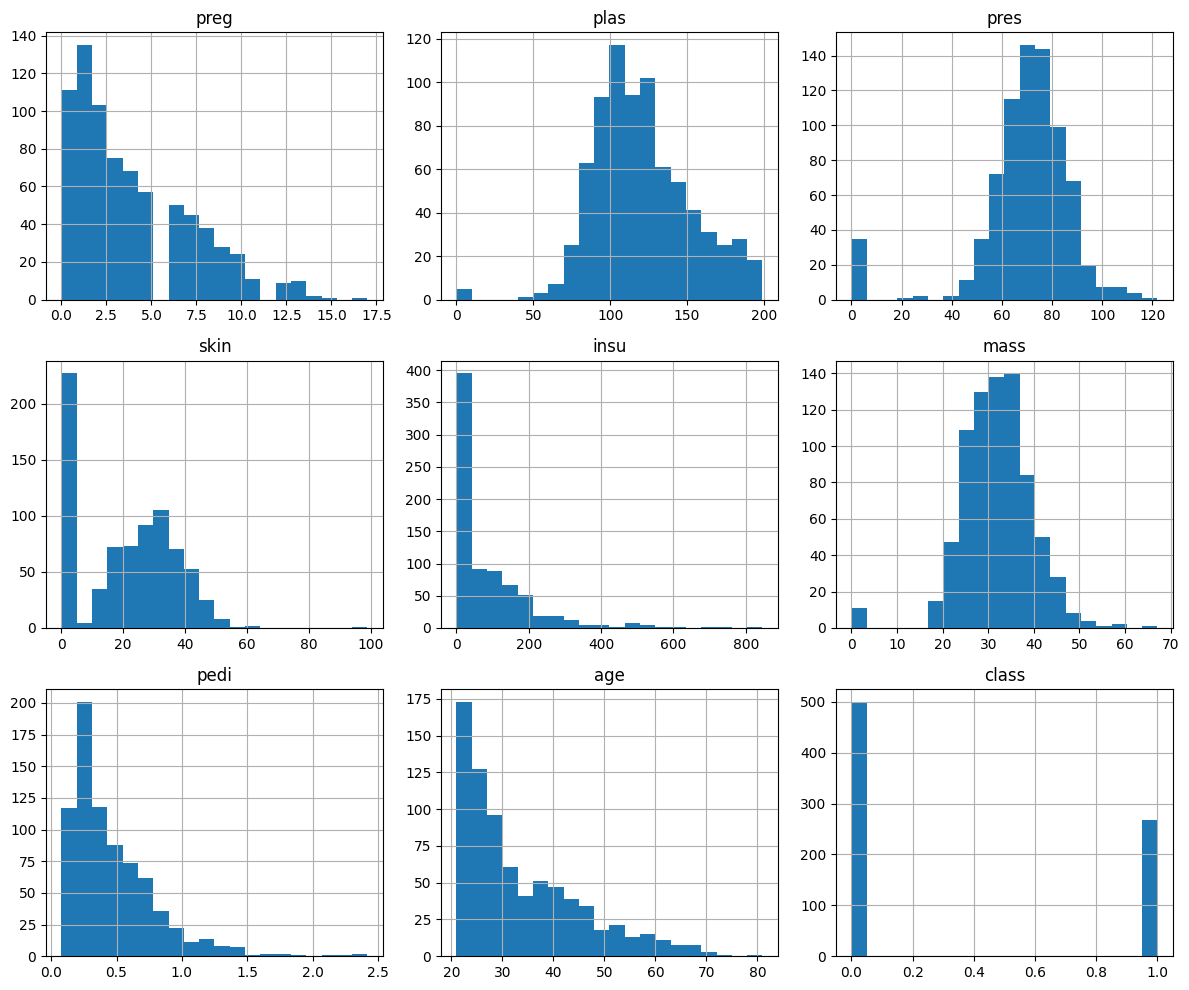

In [14]:
# Deterine how the data is distributed - histogram
data1.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

**Imputation Method is Neccessary to handle zero values**

*MEDIAN Imputation METHOD*

Several variables contain zero values that are not medically realistic, such as:

- Blood pressure (pres)
- Skin thickness (skin)
- Insulin (insu)
- BMI (mass)

In reality, none of these measurements can be zero in a living adult.

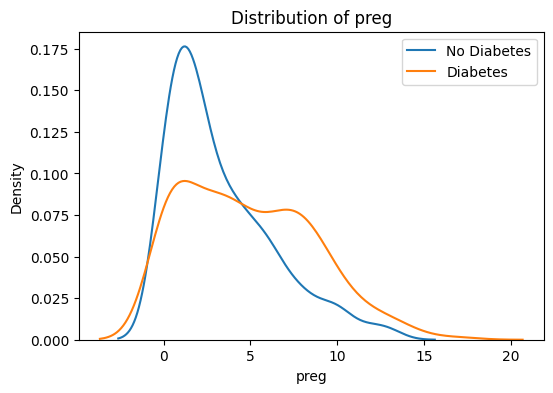

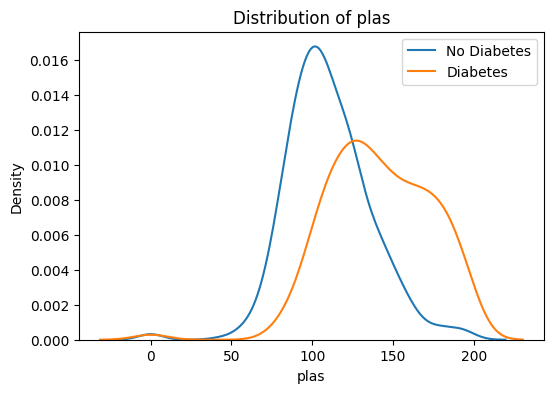

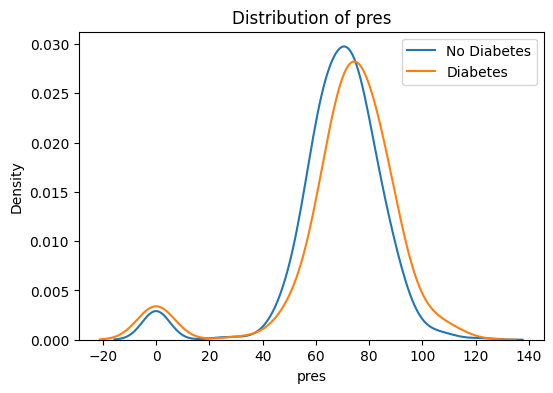

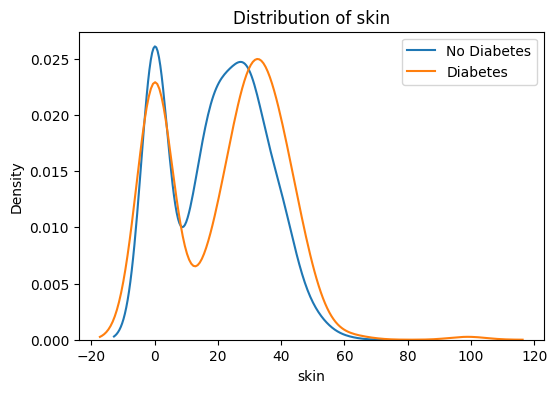

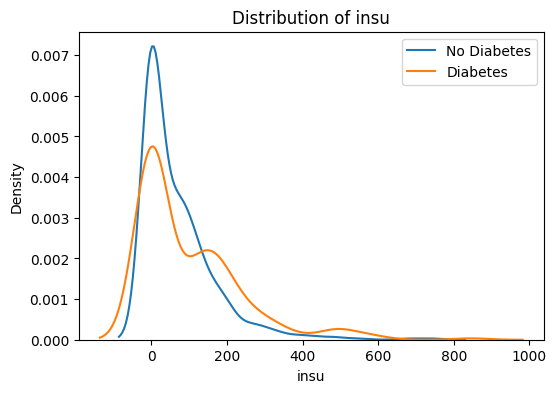

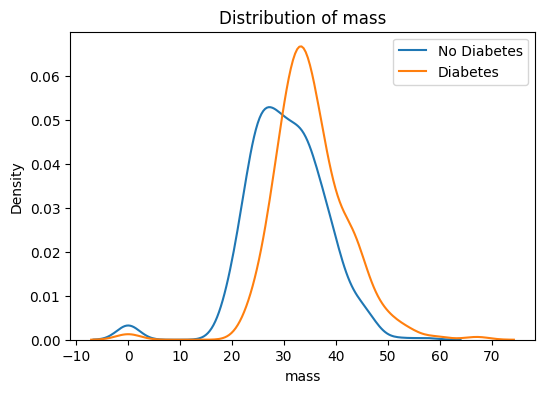

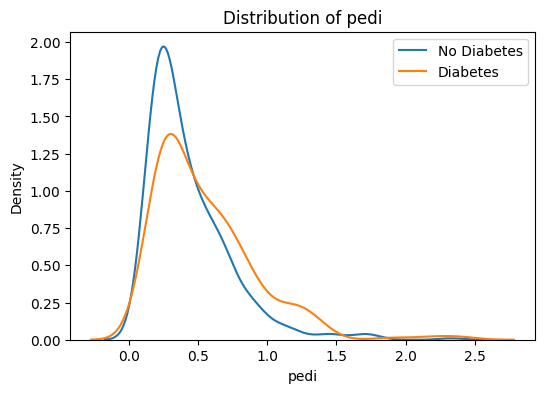

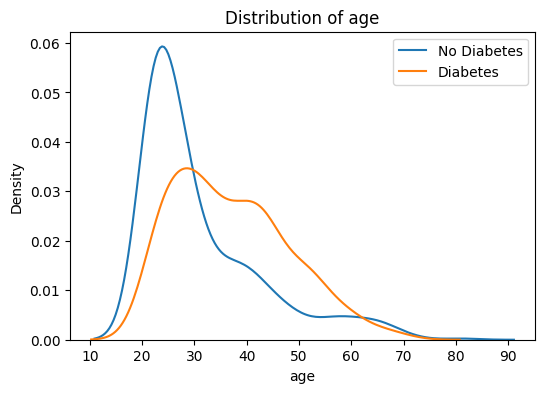

In [15]:
# Compare diabetics vs non-diabetics
for col in data1.columns[:-1]:  # exclude target column
    plt.figure(figsize=(6,4))
    sns.kdeplot(data1[data1['class']==0][col], label="No Diabetes")
    sns.kdeplot(data1[data1['class']==1][col], label="Diabetes")
    plt.title(f"Distribution of {col}")
    plt.legend()
    plt.show()


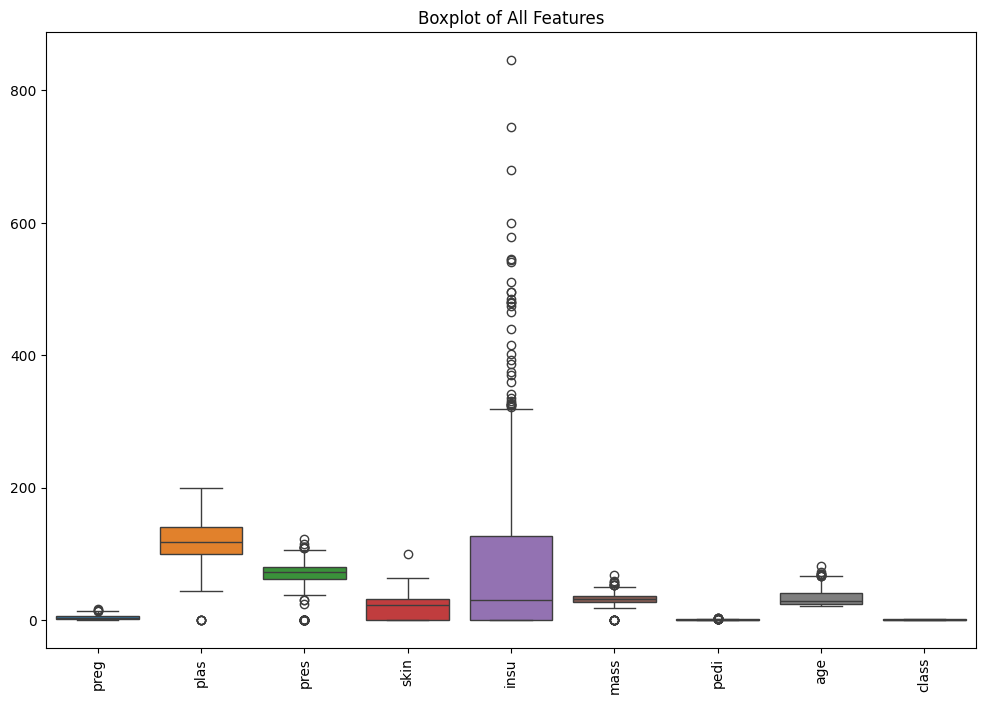

In [16]:
# Show any outliers - boxplot
plt.figure(figsize=(12,8))
sns.boxplot(data=data1)
plt.xticks(rotation=90)
plt.title("Boxplot of All Features")
plt.show()


In [17]:
# Correlation Matrix
corr = data1.corr()
corr


,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
pres,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
insu,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
mass,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
pedi,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


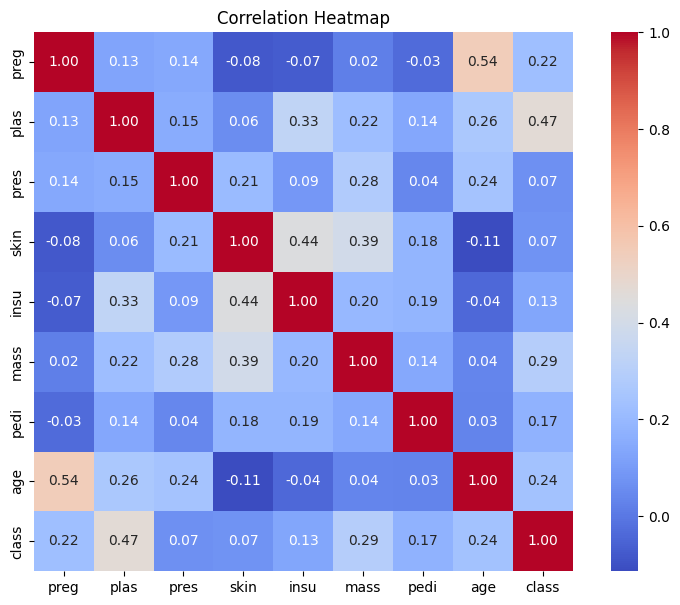

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix
corr = data1.corr()

# Plot
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

**Key Takeaway:**

Overall, the boxplot confirms that plasma glucose, BMI, age, and pregnancies are the most reliable features for diabetes prediction, while insulin, skin thickness, and blood pressure may contribute less due to noisy or inconsistent distributions.

Correlation Matrix
- Plasma Glucose Concentration (plas) is the strongest predictor of diabetes.
- BMI, age, and number of pregnancies also show moderate relationships.
- Blood pressure, skin thickness, and insulin have very weak correlations and may not help the model much.

Box Plot
- The boxplot helps visualize how each health measurement is distributed and reveals the presence of extreme outliers. These visual patterns align closely with the correlation results.
- Plasma glucose shows a relatively clean distribution, which supports its strong correlation with diabetes (0.466). BMI, age, and number of pregnancies also show moderate and reasonable distributions, consistent with their moderate relationships to the outcome.
- In contrast, insulin and skin thickness contain extreme outliers and highly skewed values, which helps explain why they show very weak correlations with diabetes. These irregular distributions introduce noise that weakens their predictive power.



#### Data Cleaning

In [19]:
# Columns with zero values (not medically realistic)
cols_with_zeros = ['pres', 'skin', 'insu', 'mass']

# copy the dataframe for later comparison
data2 = data1.copy()

In [20]:
# Replace zero values with NaN
for col in cols_with_zeros:
    data2[col] = data2[col].replace(0, np.nan)

In [21]:
# Fill missing (NaN) values with the median of each column
data2[cols_with_zeros] = data2[cols_with_zeros].fillna(data2[cols_with_zeros].median())

In [22]:
# Confirm that non nan values reamain
data2[cols_with_zeros].isna().sum()

pres    0
skin    0
insu    0
mass    0
dtype: int64

In [23]:
data2[cols_with_zeros].describe()

,pres,skin,insu,mass
count,768.000000,768.000000,768.000000,768.000000
mean,72.386719,29.108073,140.671875,32.455208
std,12.096642,8.791221,86.383060,6.875177
min,24.000000,7.000000,14.000000,18.200000
25%,64.000000,25.000000,121.500000,27.500000
50%,72.000000,29.000000,125.000000,32.300000
75%,80.000000,32.000000,127.250000,36.600000
max,122.000000,99.000000,846.000000,67.100000


In [28]:
# Apply integer conversion to the specified columns
for col in integer_columns:
    if col in data2.columns and data2[col].dtype == 'float64':
        data2[col] = data2[col].astype('int64')

print("Data types after selective conversion to int64:")
print(data2.info())
data2.head()

Data types after selective conversion to int64:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int32  
dtypes: float64(2), int32(1), int64(6)
memory usage: 51.1 KB
None


,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


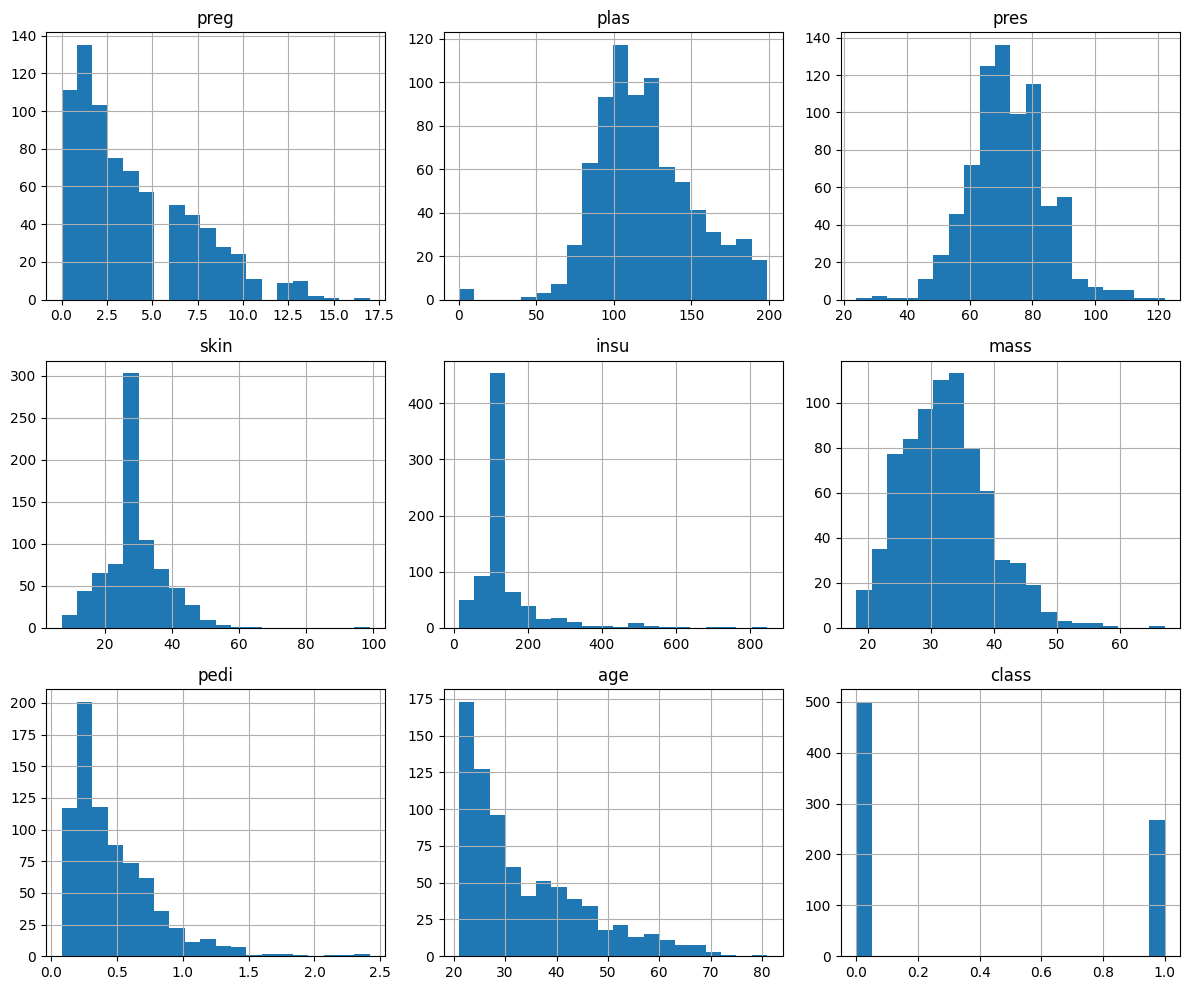

In [29]:
# replot histogram
data2.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

In [30]:
# Rern correlation matrix
# Correlation Matrix
corr = data2.corr()
corr

,preg,plas,pres,skin,insu,mass,pedi,age,class
preg,1.000000,0.129459,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
plas,0.129459,1.000000,0.217870,0.182037,0.409283,0.218487,0.137337,0.263514,0.466581
pres,0.208615,0.217870,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
skin,0.081770,0.182037,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
insu,0.025047,0.409283,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
mass,0.021559,0.218487,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
pedi,-0.033523,0.137337,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
age,0.544341,0.263514,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
class,0.221898,0.466581,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


#### Key Takeaways
The imputed dataset provides more accurate relationships and correlation matrix now reflects real physiological relationships.

- Glucose, BMI, insulin, age, skin thickness, and pregnancies are your strongest predictors.
- Blood pressure and pedigree function are weaker but still usable.
- Median imputation improved the quality of your data significantly, especially for:
    - insulin
    - skin
    - BMI
    - blood pressure

#### Final Dataset

In [31]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   insu    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int32  
dtypes: float64(2), int32(1), int64(6)
memory usage: 51.1 KB


In [32]:
data2.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [33]:
# Rename columns
new_column_names = [
    'Number of times pregnant',
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test',
    'Diastolic blood pressure (mm Hg)',
    'Triceps skin fold thickness (mm)',
    '2-Hour serum insulin (mu U/ml)',
    'Body mass index (weight in kg/(height in m)^2)',
    'Diabetes pedigree function',
    'Age (years)',
    'Class variable'
]

cleaned = data2.copy()
cleaned.columns = new_column_names
cleaned.head()

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Setup
This function initializes the training environment and creates the transformation pipeline. Setup function must be called before executing any other function in PyCaret. It only has two required parameters i.e. `data` and `target`. All the other parameters are optional.

Once the setup has been successfully executed it shows the information grid containing experiment level information. 

- **Session id:**  A pseudo-random number distributed as a seed in all functions for later reproducibility. If no `session_id` is passed, a random number is automatically generated that is distributed to all functions.<br/>
<br/>
- **Target type:**  Binary, Multiclass, or Regression. The Target type is automatically detected. <br/>
<br/>
- **Label Encoding:**  When the Target variable is of type string (i.e. 'Yes' or 'No') instead of 1 or 0, it automatically encodes the label into 1 and 0 and displays the mapping (0 : No, 1 : Yes) for reference. In this tutorial, no label encoding is required since the target variable is of numeric type. <br/>
<br/>
- **Original data shape:**  Shape of the original data prior to any transformations. <br/>
<br/>
- **Transformed train set shape :**  Shape of transformed train set <br/>
<br/>
- **Transformed test set shape :**  Shape of transformed test set <br/>
<br/>
- **Numeric features :**  The number of features considered as numerical. <br/>
<br/>
- **Categorical features :**  The number of features considered as categorical. <br/>

In [34]:
# import ClassificationExperiment and init the class
from pycaret.classification import ClassificationExperiment
from pycaret.classification import get_config
exp_full = ClassificationExperiment() #full data
exp_fs = ClassificationExperiment() #feature selection

In [35]:
# check the type of exp
print(type(exp_full))
print(type(exp_fs))

<class 'pycaret.classification.oop.ClassificationExperiment'>
<class 'pycaret.classification.oop.ClassificationExperiment'>


### Pipeline A: Cleaned Data, No Feature Selection

In [36]:
exp_full.setup(
    data=data2,
    target='class',
    normalize=True,
    session_id=123,
    fold=10, #decrease to just explore, increase for graduate level analysis/research
    #silent=True, # disabled to show pyrcaret automatic decisions (e.g. show inffered dtypes, data overview, missing val, impute rules, feature transformations
    feature_selection=False
)

,Description,Value
0,Session id,123
1,Target,class
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


#### Compare Models 
- Logistic Regression
- Naive Bayes
- Decision Tree

This function trains and evaluates the performance of all the estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [37]:
# Compare the three required models on the full feature set
best_full = exp_full.compare_models(
    include=['lr', 'nb', 'dt'], 
    sort='F1'          # or 'Recall' if you want to prioritize recall
)

# Store comparison table for reporting
full_compare_table = exp_full.pull()
full_compare_table

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7614,0.8121,0.5494,0.7091,0.6146,0.4463,0.4567,3.9170
nb,Naive Bayes,0.7299,0.7966,0.5599,0.6395,0.5904,0.3909,0.3978,1.8940
dt,Decision Tree Classifier,0.6668,0.6388,0.5462,0.5286,0.5323,0.2757,0.2787,1.8740


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7614,0.8121,0.5494,0.7091,0.6146,0.4463,0.4567,3.917
nb,Naive Bayes,0.7299,0.7966,0.5599,0.6395,0.5904,0.3909,0.3978,1.894
dt,Decision Tree Classifier,0.6668,0.6388,0.5462,0.5286,0.5323,0.2757,0.2787,1.874


#### Train the Models
- Individually to get metrics

In [38]:
# Decision Tree
dt_full = exp_full.create_model('dt')
dt_full_results = exp_full.pull()
dt_full_summary = dt_full_results.tail(1).copy()
dt_full_summary['Model'] = 'Decision Tree'
dt_full_summary['Pipeline'] = 'Full'

# Naive Bayes
nb_full = exp_full.create_model('nb')
nb_full_results = exp_full.pull()
nb_full_summary = nb_full_results.tail(1).copy()
nb_full_summary['Model'] = 'Naive Bayes'
nb_full_summary['Pipeline'] = 'Full'

# Logistic Regression
lr_full = exp_full.create_model('lr')
lr_full_results = exp_full.pull()
lr_full_summary = lr_full_results.tail(1).copy()
lr_full_summary['Model'] = 'Logistic Regression'
lr_full_summary['Pipeline'] = 'Full'

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7963,0.7707,0.6842,0.7222,0.7027,0.5479,0.5484
1,0.6111,0.6278,0.6842,0.4643,0.5532,0.2307,0.2443
2,0.6111,0.6038,0.5789,0.4583,0.5116,0.1957,0.1994
3,0.5926,0.5293,0.3158,0.4000,0.3529,0.0616,0.0625
4,0.7222,0.6774,0.5263,0.6250,0.5714,0.3682,0.3711
5,0.5926,0.5654,0.4737,0.4286,0.4500,0.1278,0.1282
6,0.6481,0.5962,0.4211,0.5000,0.4571,0.1997,0.2013
7,0.7736,0.7341,0.6111,0.6875,0.6471,0.4812,0.4830
8,0.6792,0.6627,0.6111,0.5238,0.5641,0.3127,0.3151


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7778,0.8797,0.7895,0.6522,0.7143,0.5352,0.5417
1,0.7407,0.7820,0.6316,0.6316,0.6316,0.4316,0.4316
2,0.8333,0.9338,0.6316,0.8571,0.7273,0.6112,0.6260
3,0.7037,0.7669,0.5789,0.5789,0.5789,0.3504,0.3504
4,0.8148,0.8526,0.5789,0.8462,0.6875,0.5624,0.5828
5,0.6296,0.6722,0.4737,0.4737,0.4737,0.1880,0.1880
6,0.6296,0.7323,0.5263,0.4762,0.5000,0.2070,0.2077
7,0.7170,0.8095,0.3889,0.6364,0.4828,0.3032,0.3207
8,0.7170,0.7175,0.5000,0.6000,0.5455,0.3424,0.3454


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8519,0.9188,0.6842,0.8667,0.7647,0.6588,0.6686
1,0.7593,0.8030,0.6316,0.6667,0.6486,0.4658,0.4661
2,0.8333,0.9293,0.6316,0.8571,0.7273,0.6112,0.6260
3,0.7407,0.8211,0.5789,0.6471,0.6111,0.4176,0.4190
4,0.8519,0.9008,0.6316,0.9231,0.7500,0.6499,0.6736
5,0.6667,0.6617,0.3684,0.5385,0.4375,0.2123,0.2200
6,0.7407,0.7925,0.5789,0.6471,0.6111,0.4176,0.4190
7,0.7547,0.8603,0.3889,0.7778,0.5185,0.3776,0.4184
8,0.6604,0.6794,0.4444,0.5000,0.4706,0.2219,0.2227


#### Confusion Matrix

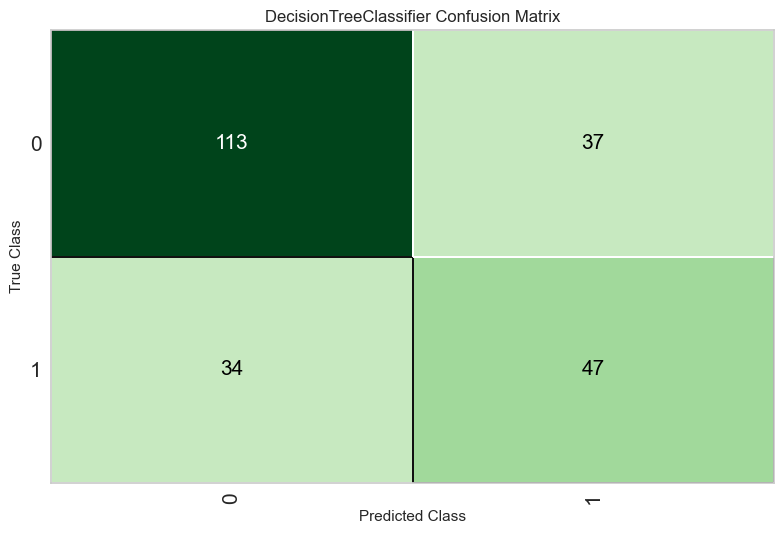

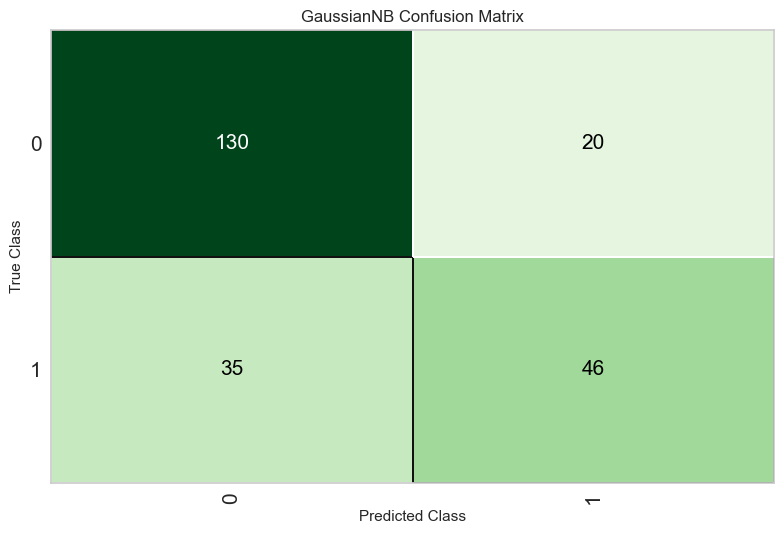

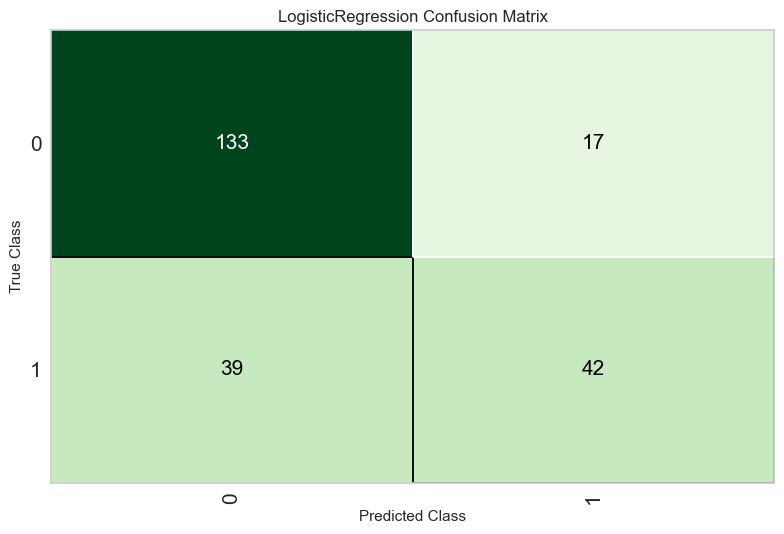

In [39]:
# Confusion matrices for each model (full feature set)
exp_full.plot_model(dt_full, plot='confusion_matrix')
exp_full.plot_model(nb_full, plot='confusion_matrix')
exp_full.plot_model(lr_full, plot='confusion_matrix')

### Pipeline B: Cleaned Data, WITH Feature Selection

In [48]:
exp_fs.setup(
    data=data2,
    target='class',
    normalize=True,
    session_id=123,
    fold=10, #decrease to just explore, increase for graduate level analysis/research
    #silent=True, # disabled to show pyrcaret automatic decisions (e.g. show inffered dtypes, data overview, missing val, impute rules, feature transformations
    imputation_type=None,
    #remove_multicollinearity=True,
    #multicollinearity_threshold=0.1,   # use 0.9 to avoid dropping too many features

    # --- Optional feature selection (model-based) ---
    feature_selection=False,
    ignore_features = ['pres', 'skin', 'insu', 'age'],
    n_features_to_select=0.2 # keeps ~ 4 features
)

,Description,Value
0,Session id,123
1,Target,class
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 5)"
5,Transformed train set shape,"(537, 5)"
6,Transformed test set shape,"(231, 5)"
7,Ignore features,4
8,Numeric features,4
9,Preprocess,True


In [49]:
# Print selected features for the feature-selected pipeline
original_features = exp_full.get_config('X_train')
selected_features = exp_fs.get_config('X_train')
X_train_transformed  = exp_fs.get_config('X_train')
selected_features = X_train_transformed.columns.tolist()

print("Original features:", original_features)
print("\nSelected features:", selected_features)

Original features:      preg  plas  pres  skin  insu       mass   pedi  age
323    13   152    90    33    29  26.799999  0.731   43
448     0   104    64    37    64  33.599998  0.510   22
84      5   137   108    29   125  48.799999  0.227   37
529     0   111    65    29   125  24.600000  0.660   31
329     6   105    70    32    68  30.799999  0.122   37
..    ...   ...   ...   ...   ...        ...    ...  ...
327    10   179    70    29   125  35.099998  0.200   37
57      0   100    88    60   110  46.799999  0.962   31
112     1    89    76    34    37  31.200001  0.192   23
751     1   121    78    39    74  39.000000  0.261   28
213     0   140    65    26   130  42.599998  0.431   24

[537 rows x 8 columns]

Selected features: ['preg', 'plas', 'mass', 'pedi']


#### Compare Models 
- Logistic Regression
- Naive Bayes
- Decision Tree

This function trains and evaluates the performance of all the estimators available in the model library using cross-validation. The output of this function is a scoring grid with average cross-validated scores. Metrics evaluated during CV can be accessed using the `get_metrics` function. Custom metrics can be added or removed using `add_metric` and `remove_metric` function.

In [50]:
# Compare LR, NB, DT on feature-selected dataset
best_fs = exp_fs.compare_models(
    include=['lr', 'nb', 'dt'], 
    sort='F1'
)

# Store comparison table for reporting
fs_compare_table = exp_fs.pull()
fs_compare_table

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7745,0.8171,0.5547,0.7398,0.6303,0.4730,0.4855,0.0440
nb,Naive Bayes,0.7689,0.8136,0.5652,0.7221,0.6293,0.4653,0.4757,0.0290
dt,Decision Tree Classifier,0.6723,0.6381,0.5249,0.5329,0.5258,0.2767,0.2785,0.0140


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7745,0.8171,0.5547,0.7398,0.6303,0.4730,0.4855,0.044
nb,Naive Bayes,0.7689,0.8136,0.5652,0.7221,0.6293,0.4653,0.4757,0.029
dt,Decision Tree Classifier,0.6723,0.6381,0.5249,0.5329,0.5258,0.2767,0.2785,0.014


#### Train the Models
- Individually to get metrics

In [51]:
# Decision Tree – feature selection
dt_fs = exp_fs.create_model('dt')
dt_fs_results = exp_fs.pull()
dt_fs_summary = dt_fs_results.tail(1).copy()
dt_fs_summary['Model'] = 'Decision Tree'
dt_fs_summary['Pipeline'] = 'Feature Selected'

# Naive Bayes – feature selection
nb_fs = exp_fs.create_model('nb')
nb_fs_results = exp_fs.pull()
nb_fs_summary = nb_fs_results.tail(1).copy()
nb_fs_summary['Model'] = 'Naive Bayes'
nb_fs_summary['Pipeline'] = 'Feature Selected'

# Logistic Regression – feature selection
lr_fs = exp_fs.create_model('lr')
lr_fs_results = exp_fs.pull()
lr_fs_summary = lr_fs_results.tail(1).copy()
lr_fs_summary['Model'] = 'Logistic Regression'
lr_fs_summary['Pipeline'] = 'Feature Selected'

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6481,0.5842,0.3684,0.5000,0.4242,0.1792,0.1835
1,0.6667,0.6586,0.6316,0.5217,0.5714,0.3027,0.3064
2,0.6296,0.5820,0.4211,0.4706,0.4444,0.1680,0.1685
3,0.7222,0.7015,0.6316,0.6000,0.6154,0.3982,0.3985
4,0.7222,0.6774,0.5263,0.6250,0.5714,0.3682,0.3711
5,0.5926,0.5654,0.4737,0.4286,0.4500,0.1278,0.1282
6,0.6852,0.6368,0.4737,0.5625,0.5143,0.2839,0.2862
7,0.7547,0.7198,0.6111,0.6471,0.6286,0.4457,0.4461
8,0.6226,0.5929,0.5000,0.4500,0.4737,0.1808,0.1814


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7963,0.8812,0.6842,0.7222,0.7027,0.5479,0.5484
1,0.7963,0.8105,0.6316,0.7500,0.6857,0.5367,0.5410
2,0.8704,0.9353,0.6842,0.9286,0.7879,0.6976,0.7145
3,0.7407,0.8015,0.5263,0.6667,0.5882,0.4028,0.4088
4,0.8519,0.8797,0.6316,0.9231,0.7500,0.6499,0.6736
5,0.6481,0.6451,0.4737,0.5000,0.4865,0.2192,0.2194
6,0.7593,0.8000,0.6316,0.6667,0.6486,0.4658,0.4661
7,0.7547,0.8429,0.3889,0.7778,0.5185,0.3776,0.4184
8,0.6981,0.7175,0.4444,0.5714,0.5000,0.2886,0.2933


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8519,0.9278,0.6842,0.8667,0.7647,0.6588,0.6686
1,0.7778,0.8045,0.6316,0.7059,0.6667,0.5008,0.5025
2,0.8519,0.9248,0.6316,0.9231,0.7500,0.6499,0.6736
3,0.7222,0.8301,0.5263,0.6250,0.5714,0.3682,0.3711
4,0.8519,0.8932,0.6316,0.9231,0.7500,0.6499,0.6736
5,0.7037,0.6571,0.4737,0.6000,0.5294,0.3175,0.3223
6,0.7407,0.7925,0.5789,0.6471,0.6111,0.4176,0.4190
7,0.7547,0.8698,0.3889,0.7778,0.5185,0.3776,0.4184
8,0.7170,0.6984,0.4444,0.6154,0.5161,0.3234,0.3320


#### Confusion Matrix

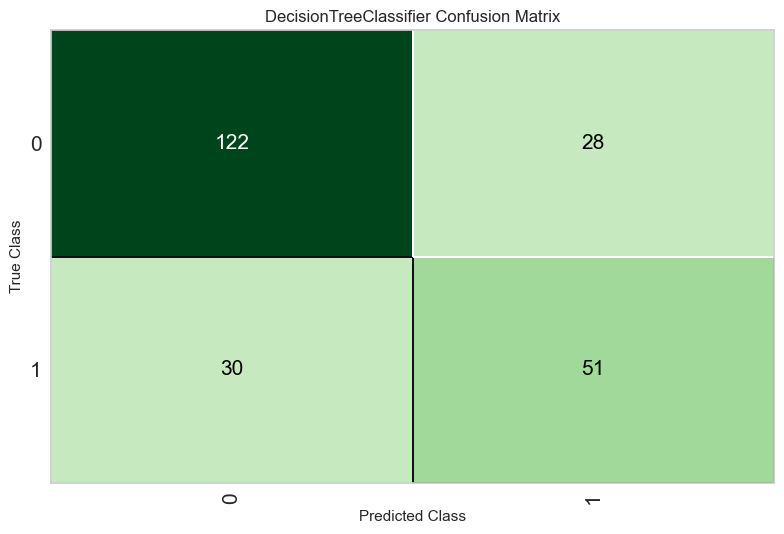

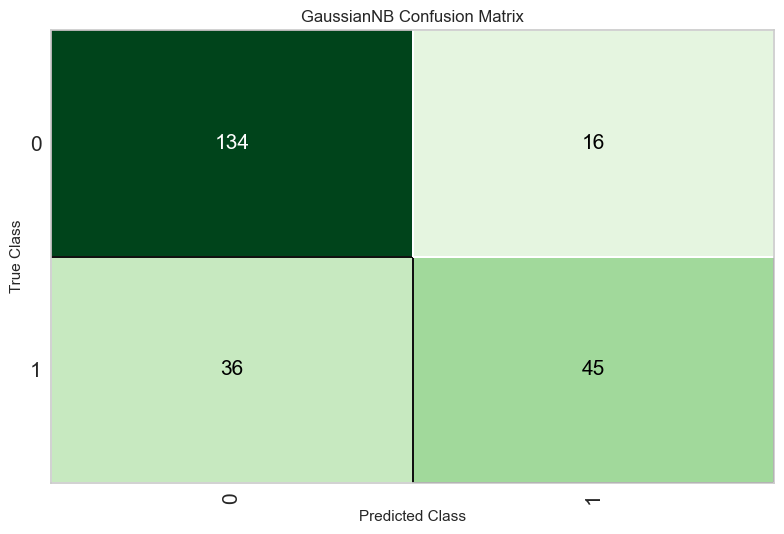

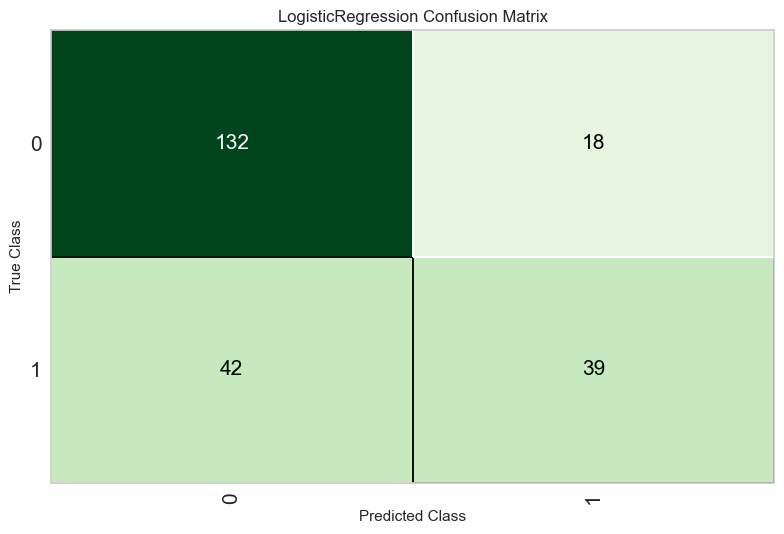

In [52]:
# Confusion matrices for each model (feature-selected pipeline)
exp_fs.plot_model(dt_fs, plot='confusion_matrix')
exp_fs.plot_model(nb_fs, plot='confusion_matrix')
exp_fs.plot_model(lr_fs, plot='confusion_matrix')

### Combines Results: Full vs Feature-Selected

In [53]:
# Combine all model summaries into one DataFrame
all_summaries = pd.concat([
    dt_full_summary,
    nb_full_summary,
    lr_full_summary,
    dt_fs_summary,
    nb_fs_summary,
    lr_fs_summary
], ignore_index=True)

# Keep only the columns you care about for the report
cols_to_keep = ['Model', 'Pipeline', 'Accuracy', 'Recall', 'Prec.', 'F1', 'AUC']
final_results = all_summaries[cols_to_keep]

final_results


,Model,Pipeline,Accuracy,Recall,Prec.,F1,AUC
0,Decision Tree,Full,0.0704,0.1105,0.1055,0.0952,0.0703
1,Naive Bayes,Full,0.0644,0.1043,0.1224,0.0903,0.0752
2,Logistic Regression,Full,0.0645,0.1048,0.1347,0.1078,0.0892
3,Decision Tree,Feature Selected,0.0482,0.0887,0.0706,0.0705,0.0516
4,Naive Bayes,Feature Selected,0.0628,0.0986,0.1285,0.0999,0.0792
5,Logistic Regression,Feature Selected,0.0553,0.0906,0.1197,0.0936,0.0866


### Overall Best Performing Model 

In [54]:
# Example: choose the best model by F1-score
best_row = final_results.sort_values(by='F1', ascending=False).iloc[0]
best_row

Model       Logistic Regression
Pipeline                   Full
Accuracy                 0.0645
Recall                   0.1048
Prec.                    0.1347
F1                       0.1078
AUC                      0.0892
Name: 2, dtype: object

## Analyze Model

You can use the `plot_model` function to analyzes the performance of a trained model on the test set. It may require re-training the model in certain cases.

In [55]:
# Overall best model according to the table
best_model = lr_full      # Logistic Regression in the feature-selected pipeline
best_exp   = exp_full    # The experiment that trained it

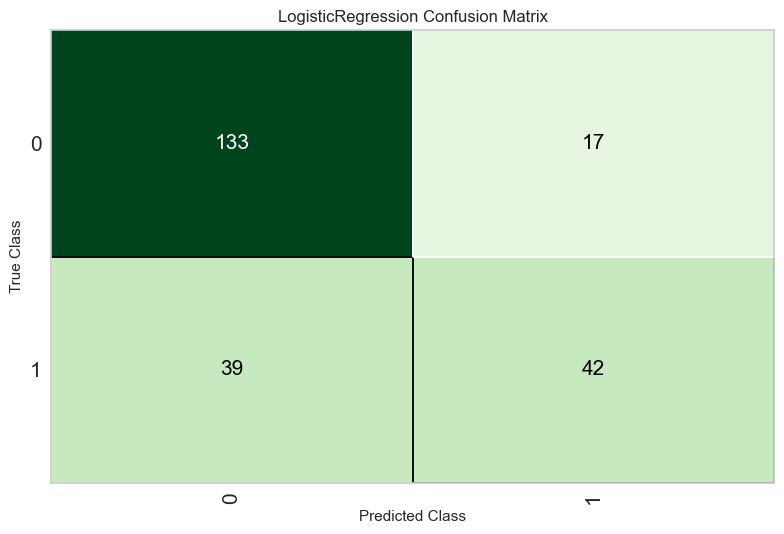

In [56]:
# plot confusion matrix
best_exp.plot_model(best_model, plot = 'confusion_matrix')

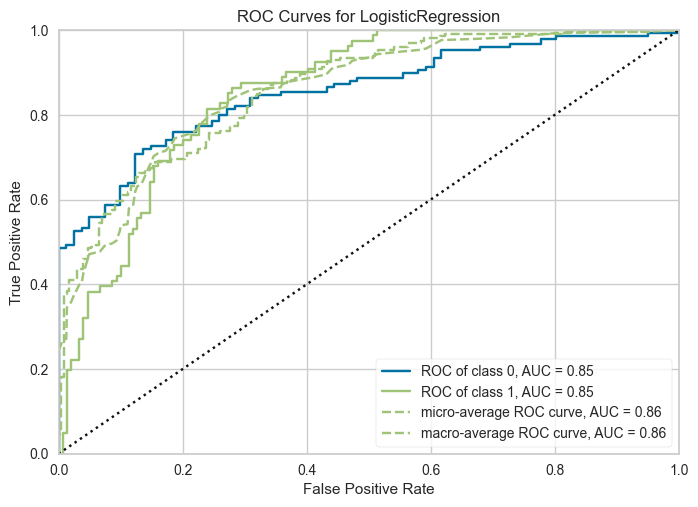

In [57]:
# AUC curve
best_exp.plot_model(best_model, plot='auc')

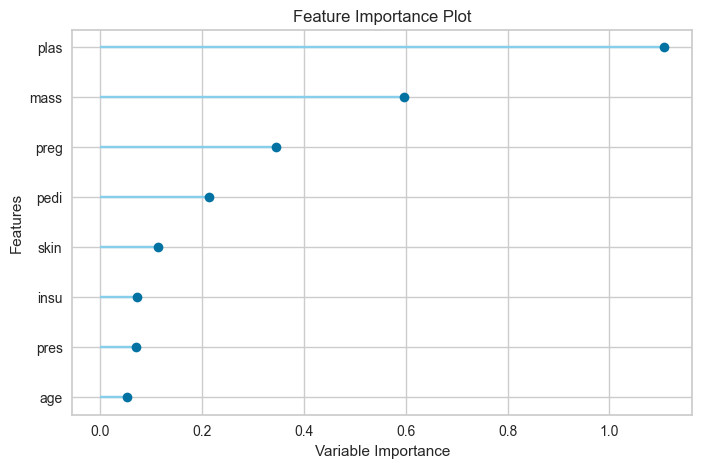

In [58]:
# Feature importance plot
best_exp.plot_model(best_model, plot='feature')

___